# Ch14 編碼器與解角器(Encoders and Resolvers)

**對應原書**:Chapter 14
**軟體替代**:ModelQ 量化方塊 → `EncoderModel` 量化模擬 + 理論雜訊公式對照

## 學習目標
1. 理解編碼器**解析度 → 速度雜訊**的放大機制:差分把量化階 $q$ 放大成 $q/T_s$。
2. 驗證理論公式:速度雜訊 RMS $\approx \dfrac{q}{\sqrt{6}\,T_s}$($q$ = 量化階 [rad])。
3. 認識補救手段的取捨:平均(降雜訊、加延遲)。

> 這個雜訊直接限制速度迴路增益 —— 第 18 章用觀測器徹底解決它。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

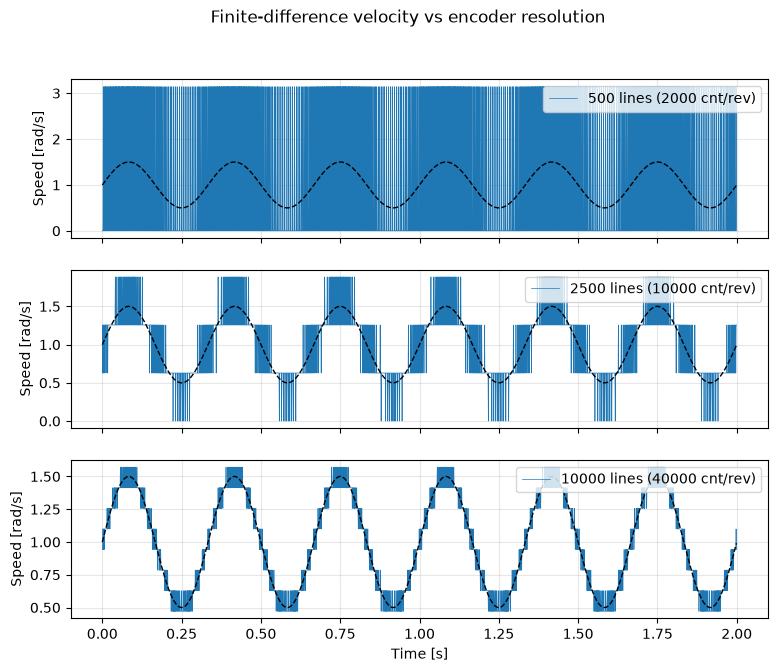

  lines     量測 RMS   理論 q/(√6·Ts)
    500     1.4130         1.2825
   2500     0.2465         0.2565
  10000     0.0659         0.0641


In [2]:
fs = 1000.0
dt = 1 / fs
n = 2000
t = np.arange(n) * dt
w_true = 1.0 + 0.5 * np.sin(2 * np.pi * 3 * t)      # 變速,避免量化誤差週期化
pos_rev = np.cumsum(w_true) * dt / (2 * np.pi)       # 位置 [rev]

results = {}
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, lines in zip(axes, [500, 2500, 10000]):
    enc = EncoderModel(lines=lines)
    pos_q = np.asarray(enc.read(pos_rev)) * 2 * np.pi   # 量化位置 [rad]
    v_fd = np.diff(pos_q, prepend=0.0) / dt
    err = v_fd[100:] - w_true[100:]
    q = 2 * np.pi / enc.counts_per_rev
    results[lines] = dict(meas=float(err.std()), theory=float(q / np.sqrt(6) / dt))
    ax.plot(t, v_fd, lw=0.5, label=f'{lines} lines ({enc.counts_per_rev} cnt/rev)')
    ax.plot(t, w_true, 'k--', lw=1)
    ax.legend(loc='upper right'); ax.grid(alpha=0.3); ax.set_ylabel('Speed [rad/s]')
axes[-1].set_xlabel('Time [s]')
plt.suptitle('Finite-difference velocity vs encoder resolution')
plt.show()

print(f"{'lines':>7} {'量測 RMS':>10} {'理論 q/(√6·Ts)':>14}")
for lines, r in results.items():
    print(f"{lines:>7} {r['meas']:>10.4f} {r['theory']:>14.4f}")

量測與理論吻合。**每提高 4 倍解析度,速度雜訊降 4 倍** —— 但高解析度編碼器貴,
所以工程上常用時域方法補救:

## 平均的取捨:雜訊 ↓、延遲 ↑

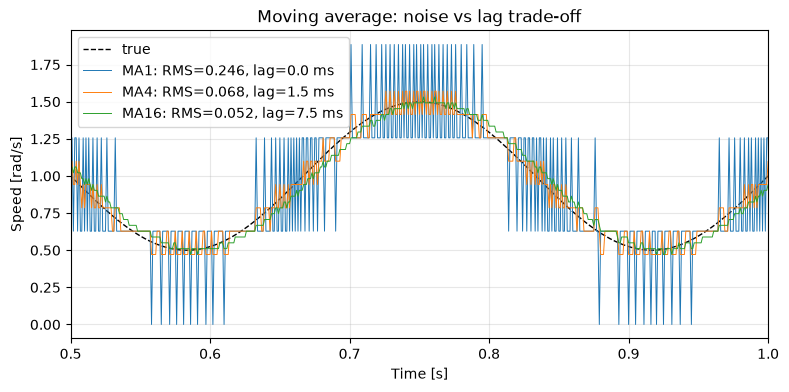

MA 1: 雜訊 RMS 0.2465,群延遲 0.0 ms
MA 4: 雜訊 RMS 0.0681,群延遲 1.5 ms
MA16: 雜訊 RMS 0.0523,群延遲 7.5 ms


In [3]:
enc = EncoderModel(lines=2500)
pos_q = np.asarray(enc.read(pos_rev)) * 2 * np.pi
v_fd = np.diff(pos_q, prepend=0.0) / dt

ma_results = {}
plt.figure(figsize=(9, 4))
plt.plot(t, w_true, 'k--', lw=1, label='true')
for N in [1, 4, 16]:
    v_ma = np.convolve(v_fd, np.ones(N) / N, mode='full')[:n]
    noise = float(np.std(v_ma[100:] - w_true[100:]))
    lag_ms = (N - 1) / 2 * dt * 1000
    ma_results[N] = dict(noise=noise, lag_ms=lag_ms)
    plt.plot(t, v_ma, lw=0.7, label=f'MA{N}: RMS={noise:.3f}, lag={lag_ms:.1f} ms')
plt.xlim(0.5, 1.0); plt.xlabel('Time [s]'); plt.ylabel('Speed [rad/s]')
plt.legend(); plt.grid(alpha=0.3); plt.title('Moving average: noise vs lag trade-off')
plt.show()
for N, r in ma_results.items():
    print(f'MA{N:>2}: 雜訊 RMS {r["noise"]:.4f},群延遲 {r["lag_ms"]:.1f} ms')

In [4]:
# ✅ 驗證
for lines, r in results.items():
    assert abs(r['meas'] - r['theory']) / r['theory'] < 0.35    # 與理論同量級(±35%)
assert results[500]['meas'] > results[2500]['meas'] > results[10000]['meas']
ratio = results[500]['meas'] / results[10000]['meas']
assert 10 < ratio < 40                                          # 解析度 20 倍 → 雜訊約 20 倍
assert ma_results[16]['noise'] < ma_results[1]['noise'] / 2     # 平均確實降雜訊
assert ma_results[16]['lag_ms'] > 5                             # 代價:延遲
print('Ch14 驗證通過 ✅')

Ch14 驗證通過 ✅


## 練習
1. 把取樣率提高到 10 kHz,同一顆編碼器的 FD 速度雜訊變大還變小?為什麼?(公式告訴你答案)
2. 實作 **1/T 法**(量測兩個 count 之間的時間取倒數),低速時與固定時間法比較。
3. 模擬 resolver:位置加上 $0.1\%$ 的一階諧波誤差(sin(θ)),看速度頻譜多出什麼成分。
4. 把 MA16 的速度餵回第 3 章的速度迴路,最大可用 kp 掉多少?